<a href="https://colab.research.google.com/github/SAIF2584/classification_algorithms/blob/main/Predicting_Heart_Disease(Cardiovascular)_using_allClassifiarAlgorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/cardio_train.csv',sep=';')

In [5]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
df['cardio'].value_counts()

,count
cardio,
0,35021
1,34979


<Axes: ylabel='count'>

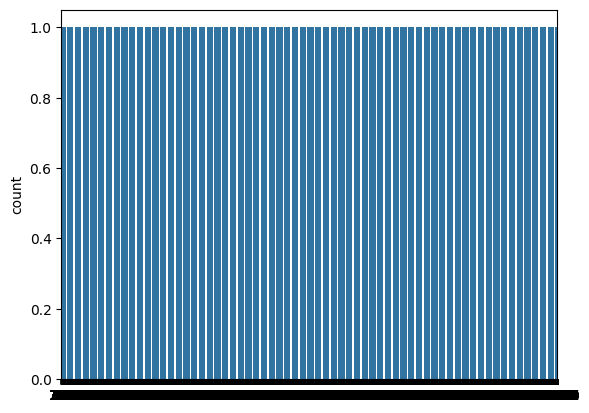

In [10]:
sns.countplot(df['cardio'])

In [13]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


<Axes: xlabel='gender', ylabel='count'>

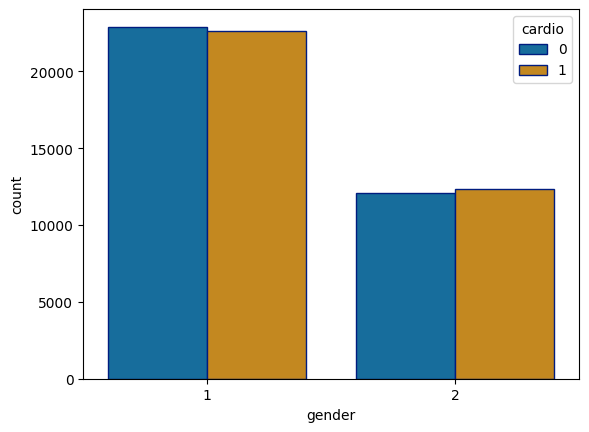

In [21]:
sns.countplot(x='gender', hue='cardio', data=df, palette='colorblind', edgecolor=sns.color_palette('dark', n_colors=1)[0])

In [22]:
df['year'] = (df['age']/365).round(0)

<Axes: xlabel='year', ylabel='count'>

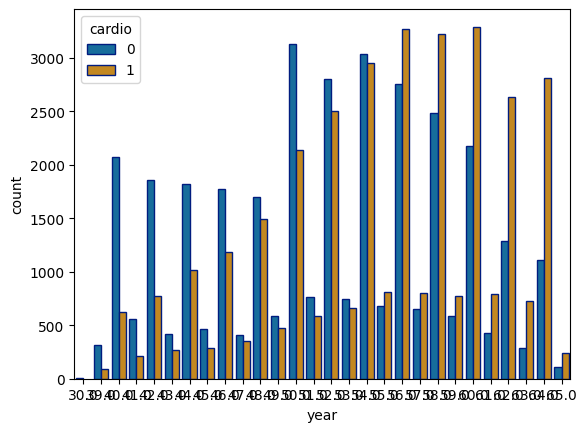

In [27]:
sns.countplot(x='year', hue='cardio', data=df, palette='colorblind', edgecolor=sns.color_palette('dark', n_colors=1)[0])

In [28]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,year
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.338686
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.765294
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


In [29]:
df.corr()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,year
id,1.000000,0.003457,0.003502,-0.003038,-0.001830,0.003356,-0.002529,0.006106,0.002467,-0.003699,0.001210,0.003755,0.003799,0.003050
age,0.003457,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159,0.999090
gender,0.003502,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109,-0.023017
height,-0.003038,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821,-0.081456
weight,-0.001830,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660,0.053661
ap_hi,0.003356,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475,0.020793
ap_lo,-0.002529,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719,0.017754
cholesterol,0.006106,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147,0.154386
gluc,0.002467,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307,0.098596
smoke,-0.003699,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486,-0.047884


In [31]:
X = df.drop(columns=['id', 'age', 'cardio'])

In [32]:
X

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,year
0,2,168,62.0,110,80,1,1,0,0,1,50.0
1,1,156,85.0,140,90,3,1,0,0,1,55.0
2,1,165,64.0,130,70,3,1,0,0,0,52.0
3,2,169,82.0,150,100,1,1,0,0,1,48.0
4,1,156,56.0,100,60,1,1,0,0,0,48.0
...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,53.0
69996,1,158,126.0,140,90,2,2,0,0,1,62.0
69997,2,183,105.0,180,90,3,1,0,1,0,52.0
69998,1,163,72.0,135,80,1,2,0,0,0,61.0


In [33]:
y = df['cardio']

In [34]:
y

,cardio
0,0
1,1
2,1
3,1
4,0
...,...
69995,0
69996,1
69997,1
69998,1


In [35]:
from sklearn.model_selection import train_test_split

In [36]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=1)

In [37]:
xtrain

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,year
23561,2,169,71.0,100,80,1,1,1,0,1,44.0
34858,1,158,69.0,140,80,2,1,0,0,1,40.0
54953,1,164,65.0,120,80,1,1,0,0,1,56.0
59230,1,153,53.0,100,60,1,1,0,0,1,46.0
1730,1,159,71.0,140,90,1,1,0,0,1,58.0
...,...,...,...,...,...,...,...,...,...,...,...
49100,2,175,78.0,120,80,1,1,0,0,1,58.0
20609,1,164,68.0,120,80,1,1,0,0,0,52.0
21440,2,178,82.0,120,80,1,1,0,0,1,49.0
50057,1,169,77.0,120,80,1,1,0,0,0,60.0


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
Rclf = RandomForestClassifier()

In [41]:
Rclf.fit(xtrain, ytrain)

RandomForestClassifier()

In [42]:
Rclf.score(xtest, ytest)

0.7062380952380952

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# 1. Define all classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# 2. Iterate, Fit, and Evaluate
results = {}
for name, model in models.items():
    # Fit the model (similar to your Rclf.fit step)
    model.fit(xtrain, ytrain)

    # Make predictions
    predictions = model.predict(xtest)

    # Calculate accuracy
    accuracy = accuracy_score(ytest, predictions)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7189
SVM Accuracy: 0.7188
KNN Accuracy: 0.6886
Decision Tree Accuracy: 0.6276
Naive Bayes Accuracy: 0.5806
Random Forest Accuracy: 0.7036
AdaBoost Accuracy: 0.7260
Gradient Boosting Accuracy: 0.7359
